# ¿Cuál fuente de origen del candidato predice mejor desempeño y permanencia del candidato?

## Importación de las librerías

In [151]:
pip -q install lifelines

Note: you may need to restart the kernel to use updated packages.


In [152]:
pip -q install scikit-survival

Note: you may need to restart the kernel to use updated packages.


In [153]:
# Funciones básicas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# Balanceo de clases
from imblearn.over_sampling import SMOTENC
# Flujo que incluye técnicas de balanceo de clases
from imblearn.pipeline import Pipeline
# Preprocesamiento de datos
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
# División del conjunto de datos en entrenamiento y prueba
from sklearn.model_selection import train_test_split
# Importación de la Regresión Logística
from sklearn.linear_model import LogisticRegressionCV
# Importación de Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier
# Métricas de clasificación
from sklearn.metrics import classification_report
# Análisis de supervivencia.
from lifelines import KaplanMeierFitter
# Aporte cada variable (feature) a la predicción de un modelo
import shap
# Ajusta el modelo de riesgos proporcionales de Cox
from lifelines import CoxPHFitter
# Medida de desempeño muy usada en análisis de supervivencia
from lifelines.utils import concordance_index
# Estima la función de supervivencia mediante el método de Kaplan–Meier.
from lifelines import KaplanMeierFitter
# Crea el objeto de supervivencia
from sksurv.util import Surv
# Mide qué tan buenas son las predicciones probabilísticas
from sksurv.metrics import brier_score

## Carga de los datos

In [154]:
df = pd.read_csv("/kaggle/input/datasets/leonardo117/data-rrhh/data_rrhh.csv")
print(df.head())

          fuente  kpi_ventas  tenure_meses  experiencia_anios nivel_educativo  \
0       LinkedIn   55.121383      7.384416           0.933816   universitario   
1    Universidad   58.748139      3.370679           2.022996   universitario   
2  Portal_empleo   73.888189      8.380267           2.546639         tecnico   
3       LinkedIn   58.261267      7.285673           1.959822       postgrado   
4      Referidos   81.126343     24.367541           1.445411   universitario   

     jefe    area  
0  Jefe A  Ventas  
1  Jefe A  Ventas  
2  Jefe A  Ventas  
3  Jefe A  Ventas  
4  Jefe B  Ventas  


### Definiendo el alto desempeño
- Para considerar un alto desempeño se tuvo que obtener una valor mayor o igual a 75 del indicador del ```kpi_ventas```.

### Definiendo una probabilidad de salida temprana (rotación)
- Se evalúa si el tiempo en la empresa es menor a 18 meses
    - **salida = 1** -> empleado con alta probabilidad de salida temprana.
    - **salida = 0** -> empleado relativamente estable.

**Observación:** La variable salida no viene de un registro de RRHH (es decir si el empleado renunció o fue despedido) sino de un criterio simple con la información disponible. 


In [155]:
df["alto_desempeno"] = (df["kpi_ventas"] >= 75).astype(int)
df["salida"] = (df["tenure_meses"] < 18).astype(int)
df.head()

,fuente,kpi_ventas,tenure_meses,experiencia_anios,nivel_educativo,jefe,area,alto_desempeno,salida
0,LinkedIn,55.121383,7.384416,0.933816,universitario,Jefe A,Ventas,0,1
1,Universidad,58.748139,3.370679,2.022996,universitario,Jefe A,Ventas,0,1
2,Portal_empleo,73.888189,8.380267,2.546639,tecnico,Jefe A,Ventas,0,1
3,LinkedIn,58.261267,7.285673,1.959822,postgrado,Jefe A,Ventas,0,1
4,Referidos,81.126343,24.367541,1.445411,universitario,Jefe B,Ventas,1,0


## Descripción de los datos

In [156]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   fuente             10000 non-null  object 
 1   kpi_ventas         10000 non-null  float64
 2   tenure_meses       10000 non-null  float64
 3   experiencia_anios  10000 non-null  float64
 4   nivel_educativo    10000 non-null  object 
 5   jefe               10000 non-null  object 
 6   area               10000 non-null  object 
 7   alto_desempeno     10000 non-null  int64  
 8   salida             10000 non-null  int64  
dtypes: float64(3), int64(2), object(4)
memory usage: 703.3+ KB


## Resumen estadístico
### Variables numéricas:

In [157]:
print(df.describe())

         kpi_ventas  tenure_meses  experiencia_anios  alto_desempeno  \
count  10000.000000  10000.000000       10000.000000    10000.000000   
mean      70.123554     23.667951           1.996706        0.312200   
std        9.997745     23.709997           2.000999        0.463414   
min       30.775997      0.001620           0.000011        0.000000   
25%       63.415946      6.832617           0.575352        0.000000   
50%       70.168068     16.486061           1.385964        0.000000   
75%       76.823764     32.435212           2.756972        1.000000   
max      114.790843    197.396116          18.240353        1.000000   

             salida  
count  10000.000000  
mean       0.533100  
std        0.498928  
min        0.000000  
25%        0.000000  
50%        1.000000  
75%        1.000000  
max        1.000000  


### Variables categóricas:

In [158]:
print(df.describe(include="object"))

          fuente nivel_educativo    jefe    area
count      10000           10000   10000   10000
unique         4               3       2       1
top     LinkedIn   universitario  Jefe B  Ventas
freq        3055            4467    5079   10000


### Desempeño promedio por fuente

In [159]:
df.groupby("fuente")["kpi_ventas"].mean().sort_values(ascending=False)

fuente
LinkedIn         70.258650
Referidos        70.245735
Portal_empleo    69.956045
Universidad      69.863648
Name: kpi_ventas, dtype: float64

**Insight observado:**

Los candidatos provenientes de ```LinkedIn``` y ```Referidos``` mostraron un mayor desempeño promedio.

**Observación:**
Cabe resaltar que solo viene a ser solo una análisis descriptivo que informa resultados pasados.

## Separación de muestras de entrenamiento y prueba

In [160]:
X = df[["fuente", "nivel_educativo", "experiencia_anios", "jefe"]]
y = df["alto_desempeno"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
y_train.value_counts()

alto_desempeno
0    5502
1    2498
Name: count, dtype: int64

**Observaciones:**
Las clases de la variable dependiente se encuentra desbalanceado

## Balanceo de las clases con SMOTENC (considerando variables categóricas)

In [161]:
cat_cols = X_train.select_dtypes(include=["object", "category"]).columns
cat_idx = [X_train.columns.get_loc(c) for c in cat_cols]
smotenc = SMOTENC(categorical_features = cat_idx, random_state=42)

## Preprocesamiento de datos

In [162]:
preprocess = ColumnTransformer(
    transformers=[("cat", OneHotEncoder(drop="first"), ["fuente", "nivel_educativo", "jefe"])],
    remainder="passthrough")
    # force_int_remainder_cols=False]

## Regresión logística – Probabilidad de alto desempeño

In [163]:
pipeline_log = Pipeline(steps=[
    ("smote", smotenc),
    ("preprocess", preprocess),
    ("model", LogisticRegressionCV(
        solver="lbfgs",
        l1_ratios=(0.0,),
        use_legacy_attributes=True,
        random_state=42)
    )])
pipeline_log.fit(X_train, y_train)

,steps,"[('smote', ...), ('preprocess', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,categorical_features,"[0, 1, ...]"
,categorical_encoder,None
,sampling_strategy,'auto'
,random_state,42
,k_neighbors,5
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'


### Métricas de clasificación - Regresión Logística

In [164]:
y_predict_log = pipeline_log.predict(X_test)
print(classification_report(y_test, y_predict_log))

              precision    recall  f1-score   support

           0       0.68      0.46      0.55      1376
           1       0.31      0.52      0.39       624

    accuracy                           0.48      2000
   macro avg       0.49      0.49      0.47      2000
weighted avg       0.56      0.48      0.50      2000



### Análisis de los ODDS RATIO
- Utilizado para cuantifica la asociación entre una variable independiente y la ocurrencia de un evento (desempeño alto).
- $odds: \text{Mide que tan probable es que ocurra un evento comparado con que no ocurra}$
$$
odds = \frac{P(evento)}{P(\text{no evento})}
$$

- $\text{odds ratio}: \text{compara las probabilidades (odds) que ocurra un evento en un grupo frente a las probabilidades de que ocurra en otro grupo.}$

$$
OR = \frac{\text{odds del grupo expuesto}}{\text{odds del grupo no expuesto}}
$$

- $\text{odds ratio en una regresión logística se interpreta mediante:}$
$$
OR = e^\beta
$$
$$
 \beta \text{: es el coeficiente del modelo}
$$ 
$$
\text{Cada coeficiente corresponde a una variable independiente}
$$
$$
\text {El OR se obtiene elevándolo a ese coeficiente}
$$

In [165]:
names_features = pipeline_log["preprocess"].get_feature_names_out()
names_features = [name.replace("remainder__","").replace("cat__","") for name in names_features]
coefs_importances = pd.Series(pipeline_log["model"].coef_[0], index=names_features).sort_values(ascending=False)
odds_ratio = (coefs_importances.to_frame(name="coeficientes")
             .assign(odds_ratio=lambda x: np.exp(x["coeficientes"]))
             .assign(coefs_abs=lambda x: np.abs(x["coeficientes"]))
              .reset_index()
             .rename(columns={"index":"variable"}))
print(odds_ratio.sort_values(by="coefs_abs", ascending=False))

                        variable  coeficientes  odds_ratio  coefs_abs
6             fuente_Universidad     -0.181538    0.833987   0.181538
5           fuente_Portal_empleo     -0.128060    0.879800   0.128060
4               fuente_Referidos     -0.058856    0.942843   0.058856
0                    jefe_Jefe B      0.039896    1.040703   0.039896
3              experiencia_anios     -0.023759    0.976521   0.023759
1  nivel_educativo_universitario      0.021750    1.021989   0.021750
2        nivel_educativo_tecnico      0.007930    1.007961   0.007930


**Conclusiones:**
- Los postulantes provenientes de la bolsa de trabajo de la universidad tienen menor probabilidad relativa de alcanzar un alto desempeño en comparación con el grupo de referencia.

## Random Forest – Variables que explican mejor el desempeño alto

In [166]:
pipeline_rf = Pipeline(steps=[
    ("smote", smotenc),
    ("preprocess", preprocess),
    ("model", RandomForestClassifier(random_state=42))
])
pipeline_rf.fit(X_train, y_train)

,steps,"[('smote', ...), ('preprocess', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,categorical_features,"[0, 1, ...]"
,categorical_encoder,None
,sampling_strategy,'auto'
,random_state,42
,k_neighbors,5
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'


### Análisis de ```features_importances_```

- Es un vector numérico donde cada valor corresponde a una característica de entrada y mide su contribución relativa al desempeño del modelo.
- Los valores están normalizados, por lo que:
$$
\Sigma \text{ features\_importances\_} = 1
$$

- Un valor más alto ⇒ la variable fue más relevante para las predicciones.

In [167]:
names_features = pipeline_rf["preprocess"].get_feature_names_out()
names_features = [name.replace("remainder__", "").replace("cat__", "") for name in names_features]
feature_importances = pd.Series(pipeline_rf["model"].feature_importances_, index=names_features).sort_values(ascending=False)
feature_importances

experiencia_anios                0.980520
jefe_Jefe B                      0.004539
nivel_educativo_universitario    0.003763
fuente_Referidos                 0.003138
nivel_educativo_tecnico          0.002952
fuente_Portal_empleo             0.002788
fuente_Universidad               0.002299
dtype: float64

**Insight observado**

El modelo de Random Forest identifica a los años de experiencia como la variable dominante para explicar el alto desempeño laboral. Lo que se podría inferir que el desempeño alto está principalmente asociado a la experiencia acumulada del trabajador.

### Métricas de clasificación - Random Forest

In [168]:
y_predict = pipeline_rf.predict(X_test)
print(classification_report(y_test, y_predict))

              precision    recall  f1-score   support

           0       0.70      0.58      0.63      1376
           1       0.33      0.46      0.38       624

    accuracy                           0.54      2000
   macro avg       0.51      0.52      0.51      2000
weighted avg       0.58      0.54      0.55      2000



## Análisis SHAP

- $\text{La predicción se descompone así:}$
$$
Predicción = \text{valor base} + \sum \text{valores SHAP}
$$

$$
\text{Valor base: valor esperador de la predicción del modelo}
$$
$$
\text{Valor SHAP: contribución individual de cada variable}
$$
$\text{Cada valor SHAP representa el efecto marginal promedio de una variable considerando todas las combinaciones posibles de variables}$

In [169]:
# preprocess = pipeline_rf["preprocess"]
# model = pipeline_rf["model"]

# X_test_proc = preprocess.transform(X_test)

# if hasattr(X_test_proc, "toarray"):
#     X_test_proc = X_test_proc.toarray()

# feature_names = preprocess.get_feature_names_out()

# print("X:", X_test_proc.shape)
# explainer = shap.TreeExplainer(model)
# shap_values = explainer.shap_values(X_test_proc)
# print("SHAP:", shap_values[8].shape)
# print("Names:", len(feature_names))

In [170]:
# shap_values_clase1 = shap_values[:, :, 1]

# shap.summary_plot(shap_values_clase1,
#                   X_test_proc,
#                   feature_names=feature_names,
#                   rng=np.random.default_rng(42),
#                   show = False)

# plt.gcf().set_size_inches(10, 5)
# plt.title("Análisis SHAP – Clase 1")
# plt.show()

**Conclusiones:**
- El análisis SHAP muestra que ninguna de las variables presenta un efecto fuerte sobre la predicción de la clase minoritaria (alto desempeño).
- Esto sugiere que el modelo no logra identificar patrones claros que expliquen la pertenencia a dicha clase.
- Se infiere que este problemapodría estar relacionada con la estructura del conjunto de datos, lo cual es coherente dado que el dataset fue creado exclusivamente con fines ilustrativos para este ejemplo.

## Modelo de riesgos proporcionales de Cox 

In [171]:
df_cox = pd.get_dummies(df, columns=["fuente", "nivel_educativo", "jefe", "area"],
                        drop_first=True).astype(int)

cph = CoxPHFitter()
cph.fit(df_cox, duration_col="tenure_meses", event_col="salida")
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 10000 total observations, 4669 right-censored observations>
             duration col = 'tenure_meses'
                event col = 'salida'
      baseline estimation = breslow
   number of observations = 10000
number of events observed = 5331
   partial log-likelihood = -47320.74
         time fit was run = 2026-05-04 03:37:41 UTC

---
                               coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                      
kpi_ventas                    -0.00      1.00      0.00           -0.01            0.00                0.99                1.00
experiencia_anios             -0.00      1.00      0.01           -0.02            0.01                0.98                1.01
alto_desempeno                -0.01      0.99      0.05           -0.10            0.08                0.91                1.09
fuente_Portal_empleo           0.00      1.00      0.04           -0.07            0.08                0.93                1.08
fuente_Referidos               0.04      1.04      0.04           -0.02            0.11                0.98                1.12
fuente_Universidad             0.05      1.05      0.04           -0.04            0.13                0.96                1.14
nivel_educativo_tecnico       -0.02      0.98      0.04           -0.09            0.06                0.91                1.06
nivel_educativo_universitario -0.00      1.00      0.04           -0.08            0.07                0.93                1.07
jefe_Jefe B                   -0.01      0.99      0.03           -0.07            0.04                0.93                1.04

                               cmp to     z    p  -log2(p)
covariate                                                 
kpi_ventas                       0.00 -1.61 0.11      3.23
experiencia_anios                0.00 -0.28 0.78      0.36
alto_desempeno                   0.00 -0.12 0.90      0.15
fuente_Portal_empleo             0.00  0.09 0.93      0.11
fuente_Referidos                 0.00  1.26 0.21      2.26
fuente_Universidad               0.00  1.04 0.30      1.76
nivel_educativo_tecnico          0.00 -0.47 0.64      0.65
nivel_educativo_universitario    0.00 -0.10 0.92      0.13
jefe_Jefe B                      0.00 -0.51 0.61      0.72
---
Concordance = 0.51
Partial AIC = 94659.47
log-likelihood ratio test = 10.14 on 9 df
-log2(p) of ll-ratio test = 1.56

**Conlusión estadística:**
- Bajo el modelo de riesgos proporcionales de Cox, ninguna de las covariables analizadas muestra una asociación estadísticamente significativa **(todas tienen un valor de p > 0.05)** con el riesgo de salida del colaborador.

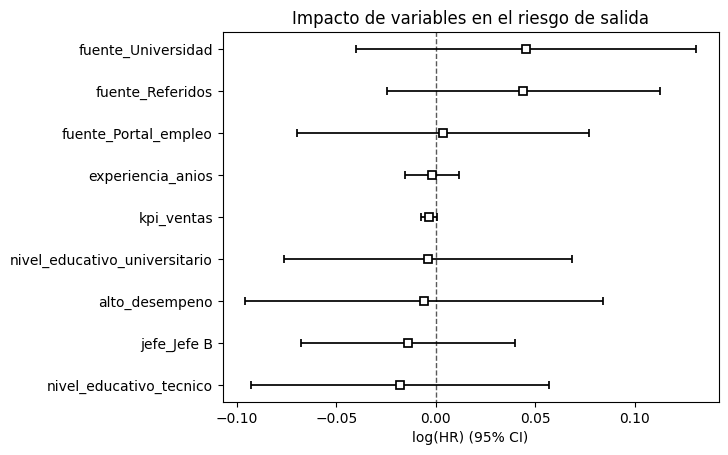

In [172]:
cph.plot()
plt.title("Impacto de variables en el riesgo de salida")
plt.show()

**Conclusión:**

- Ninguna variable es estadísticamente significativa, ya que los intervalos no cruzan completamente el 0.

## Métricas de evaluación del desempeño del modelo de riesgo

- **C-index (Índice de concordancia):**
Métrica de discriminación del riesgo, que mide qué tan bien el modelo ordena a los individuos según su riesgo, asignando mayor riesgo a quienes experimentan el evento antes.

$$
\text {Probabilidad de que el modelo asigne mayor riesgo a quien ocurre antes el evento.}
$$
$$
C=P(\hat r_i > \hat r_j | t_i < t_j)
$$
$$
\text{Baremo del C-index, medida de discriminación de un modelo de supervivencia}
$$
$$
\begin{aligned}
0.5 &\rightarrow \text{No discriminación (equivalante al azar)} \\
0.5 - 0.6 &\rightarrow \text{Muy pobre} \\
0.6 - 0.7 &\rightarrow \text{Pobre / Aceptable bajo} \\
0.7 - 0.8 &\rightarrow \text{Bueno} \\
0.8 - 0.9 &\rightarrow \text{Muy bueno} \\
{> 0.90} &\rightarrow \text{Excelente (raro en datos reales)} \\
{1.00} &\rightarrow \text{Perfecto (sospechoso / sobreajuste)} \\
\end{aligned}
$$


- **Brier Score:** Métrica de calibración y precisión probabilística, que evalúa qué tan cercanas son las probabilidades predichas por el modelo a los resultados observados.

    - $Y_i \in \{0,1\}: \text{resultado observado}$
    - $\hat p_i: \text{probabilidad predicha de } Y_i=1$

$$
BS=\frac{1}{n}\sum_{i=1}^{n}(\hat p_i-Y_i)^2
$$

$$
\text{Baremo del Brier Score, mide la calidad de las predicciones probabilísticas, evaluando que tan cerca están las probabilidades predichas de los resultados reales.}
$$
$$
\begin{aligned}
0.00 - 0.05 &\rightarrow \text{Excelente} \\
0.05 - 0.10 &\rightarrow \text{Muy bueno} \\
0.10 - 0.20 &\rightarrow \text{Aceptable} \\
0.20 - 0.30 &\rightarrow \text{Pobre} \\
{> 0.30} &\rightarrow \text{Muy malo} \\
\end{aligned}
$$

## Análisis de supervivencia aplicado a riesgo de renuncia

### Análisis del C-index

In [173]:
df_copy = df.copy()
df_copy = df_copy.drop(["area"], axis=1)

df_pre = preprocess.fit_transform(df_copy)
df_pre = pd.DataFrame(df_pre, columns=preprocess.get_feature_names_out())
df_pre.columns = [column.replace("cat__","").replace("remainder__","") for column in df_pre.columns]

df_train, df_test = train_test_split(df_pre, test_size=0.3, random_state=42)

cph = CoxPHFitter(penalizer=0.1)
cph.fit(df_train, duration_col="tenure_meses", event_col="salida")

cindex_train = cph.score(df_train, scoring_method="concordance_index")
print(f"C-index (train): {cindex_train:.3f}")

# Predicción de riesgo (hazard parcial)
risk_scores_test = cph.predict_partial_hazard(df_test)
cindex_test = concordance_index(df_test["tenure_meses"],
                                -risk_scores_test,   # signo negativo: mayor riesgo → menor tiempo
                                df_test["salida"])
print(f"C-index (test): {cindex_test:.3f}")

df_test = df_test.copy()
df_test["riesgo_renuncia"] = cph.predict_partial_hazard(df_test)
df_test["nivel_riesgo_renuncia"] = pd.qcut(df_test["riesgo_renuncia"],
                                           q=3, labels=["Bajo", "Medio", "Alto"])

C-index (train): 0.510
C-index (test): 0.509


#### Interpretación:
- El modelo presentó un índice de concordancia (**C-index**) de **0.510** en el conjunto de entrenamiento y de **0.509** en el conjunto de prueba, lo que indica una capacidad de discriminación muy baja, cercana a un desempeño al azar.
- Este resultado es esperado, ya que el análisis se realizó sobre un dataset sintético, el cual no sigue los patrones o estructuras presentes en datos reales.

 ### Análisis de Brier Score

In [174]:
# Objetos de supervivencia
y_train = Surv.from_dataframe(event="salida",
                              time="tenure_meses",
                              data=df_train)
y_test = Surv.from_dataframe(event="salida",
                             time="tenure_meses",
                             data=df_test)
# Horizonte temporal
times = np.array([12])
# Predicciones de supervivencia
surv_preds = cph.predict_survival_function(df_test, times=times)
S_pred = surv_preds.T.values  # (n_samples, n_times)
# Brier score IPCW
times_out, brier_scores = brier_score(survival_train=y_train,
                                      survival_test=y_test,
                                      estimate=S_pred,
                                      times=times)
print(f"Brier score IPCW a {times_out[0]} meses: {brier_scores[0]:.4f}")

Brier score IPCW a 12 meses: 0.2389


#### Interpretación:
- La evaluación de Brier Score ajustado por censura (**IPCW**) a los 12 meses arrojó un valor de **0.2389**. Dado que el Brier Score toma valores entre 0 y 1, donde valores más bajos indican mejor desempeño, este resultado sugiere un nivel de error relativamente elevado en la predicción de probabilidades de supervivencia al tiempo evaluado (12 meses) evaluado.
- Estos resultados deben interpretarse considerando que el análisis se realizó utilizando un dataset sintético.

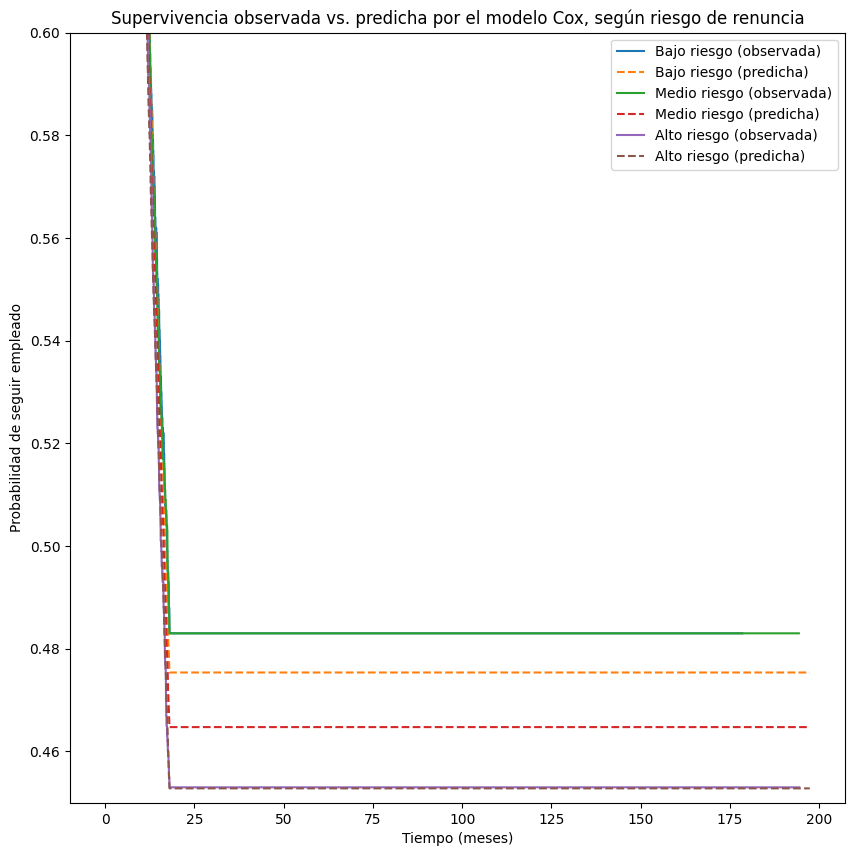

In [175]:
kmf = KaplanMeierFitter()
plt.figure(figsize=(10, 10))

for nivel in df_test["nivel_riesgo_renuncia"].unique():
    subset = df_test[df_test["nivel_riesgo_renuncia"] == nivel]
    # Curva OBSERVADA (KM)
    kmf.fit(subset["tenure_meses"],
            subset["salida"], label=f"{nivel} riesgo (observada)")
    kmf.plot(ci_show=False)
    # Curva PREDICHA (Cox)
    surv_pred = cph.predict_survival_function(subset)
    # Promedio de supervivencia del grupo
    mean_surv = surv_pred.mean(axis=1)
    plt.plot(mean_surv.index,
             mean_surv.values,
             linestyle="--",
             label=f"{nivel} riesgo (predicha)")
plt.title("Supervivencia observada vs. predicha por el modelo Cox, según riesgo de renuncia")
plt.xlabel("Tiempo (meses)")
plt.ylabel("Probabilidad de seguir empleado")
plt.ylim([0.45, 0.60])
plt.legend()
plt.show()

#### Interpretación:
- **Eje X (Tenure – meses)**: el tiempo de permanencia en el puesto.
- **Eje Y (Probabilidad de supervivencia)**: la probabilidad de que una persona siga en el empleo más allá de ese tiempo
- **La curva desciende con el tiempo:** a medida que pasan los meses, aumenta la probabilidad de salida y disminuye la probabilidad de seguir.
Por ejemplo, alrededor de **12 meses** la supervivencia está cerca de 0.6: aproximadamente 60 % seguiría empleado después de un año.
- Las líneas predichas están muy cercanas a las observadas en los 3 grupos.
- En conclusión el modelo distingue bien entre los empleados de bajo, medio y alto riesgo.
- El gráfico de Kaplan–Meier muestra que la probabilidad de permanencia laboral disminuye rápidamente durante los primeros **20 meses**, independientemente del nivel de riesgo de renuncia. Las curvas se estabilizan alrededor del **45%–50%**, lo que indica que los trabajadores que superan el periodo inicial tienden a permanecer a largo plazo.

## Análisis de supervivencia tomando en cuenta las fuentes de origen de los candidatos

In [176]:
preprocess1 = ColumnTransformer(
    transformers=[("cat", OneHotEncoder(drop="first"), ["nivel_educativo", "jefe"])],
    remainder="passthrough")
    # force_int_remainder_cols=False)

df_pre1 = preprocess1.fit_transform(df)
df_pre1 = pd.DataFrame(df_pre1, columns=preprocess1.get_feature_names_out())
df_pre1.columns = [column.replace("cat__","").replace("remainder__","") for column in df_pre1.columns]
df_pre1 = df_pre1.drop("area", axis=1)

In [177]:
df_pre1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   nivel_educativo_tecnico        10000 non-null  object
 1   nivel_educativo_universitario  10000 non-null  object
 2   jefe_Jefe B                    10000 non-null  object
 3   fuente                         10000 non-null  object
 4   kpi_ventas                     10000 non-null  object
 5   tenure_meses                   10000 non-null  object
 6   experiencia_anios              10000 non-null  object
 7   alto_desempeno                 10000 non-null  object
 8   salida                         10000 non-null  object
dtypes: object(9)
memory usage: 703.3+ KB


In [178]:
cols = df_pre1.columns.drop("fuente")
df_pre1[cols] = df_pre1[cols].apply(pd.to_numeric, errors="coerce")

In [179]:
df_pre1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   nivel_educativo_tecnico        10000 non-null  float64
 1   nivel_educativo_universitario  10000 non-null  float64
 2   jefe_Jefe B                    10000 non-null  float64
 3   fuente                         10000 non-null  object 
 4   kpi_ventas                     10000 non-null  float64
 5   tenure_meses                   10000 non-null  float64
 6   experiencia_anios              10000 non-null  float64
 7   alto_desempeno                 10000 non-null  int64  
 8   salida                         10000 non-null  int64  
dtypes: float64(6), int64(2), object(1)
memory usage: 703.3+ KB


### Análsis de C-index

In [180]:
df_train1, df_test1 = train_test_split(df_pre1, test_size=0.2, random_state=42)

cph = CoxPHFitter(penalizer=0.1)
cph.fit(df_train1.drop("fuente", axis=1), duration_col="tenure_meses", event_col="salida")

cindex_train = cph.score(df_train1, scoring_method="concordance_index")
print(f"C-index (train): {cindex_train:.3f}")

# predicción de riesgo (hazard parcial)
risk_scores_test = cph.predict_partial_hazard(df_test1)
cindex_test = concordance_index(df_test1["tenure_meses"],
                                -risk_scores_test,   # signo negativo: mayor riesgo → menor tiempo
                                df_test1["salida"])
print(f"C-index (test): {cindex_test:.3f}")

C-index (train): 0.507
C-index (test): 0.517


#### Interpretación:
- El modelo presentó un índice de concordancia (**C-index**) de **0.507** en el conjunto de entrenamiento y de **0.517** en el conjunto de prueba, lo que indica una capacidad de discriminación muy baja, cercana a un desempeño al azar.
- Este resultado es esperado, ya que el análisis se realizó sobre un dataset sintético, el cual no sigue los patrones o estructuras presentes en datos reales.

### Análisis de Brier Score

In [181]:
# objetos de supervivencia
y_train = Surv.from_dataframe(event="salida",
                              time="tenure_meses",
                              data=df_train1)
y_test = Surv.from_dataframe(event="salida",
                             time="tenure_meses",
                             data=df_test1)
# Horizonte temporal
times = np.array([12])
# Predicciones de supervivencia
surv_preds = cph.predict_survival_function(df_test1, times=times)
S_pred = surv_preds.T.values  # (n_samples, n_times)
# Brier score IPCW
times_out, brier_scores = brier_score(survival_train=y_train,
                                      survival_test=y_test,
                                      estimate=S_pred,
                                      times=times)
print(f"Brier score IPCW a {times_out[0]} meses: {brier_scores[0]:.4f}")

Brier score IPCW a 12 meses: 0.2393


#### Interpretación:
- La evaluación de Brier Score ajustado por censura (**IPCW**) a los 12 meses arrojó un valor de **0.2393**. Dado que el Brier Score toma valores entre 0 y 1, donde valores más bajos indican mejor desempeño, este resultado sugiere un nivel de error relativamente elevado en la predicción de probabilidades de supervivencia al tiempo evaluado (12 meses).
- Estos resultados deben interpretarse considerando que el análisis se realizó utilizando un dataset sintético.

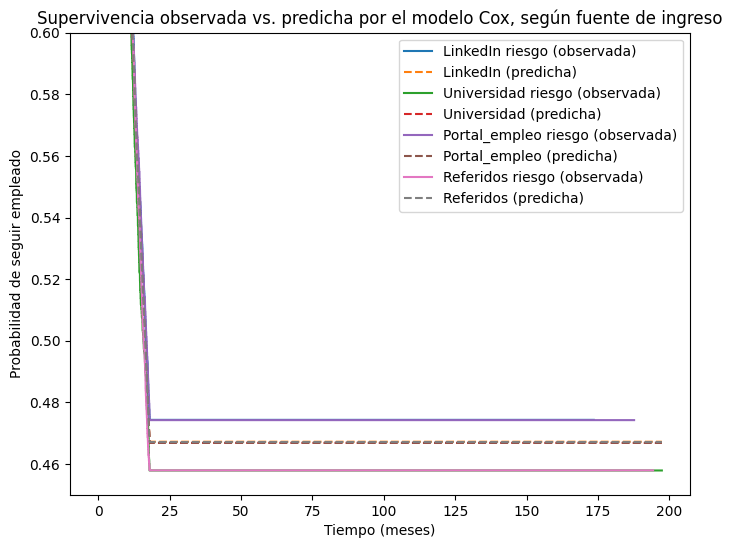

In [182]:
kmf = KaplanMeierFitter()
plt.figure(figsize=(8, 6))

for fuente in df_pre1["fuente"].unique():
    subset = df_pre1[df_pre1["fuente"] == fuente]
    # curva OBSERVADA (KM)
    kmf.fit(subset["tenure_meses"],
            subset["salida"], label=f"{fuente} riesgo (observada)")
    kmf.plot(ci_show=False)
    X_subset = subset[cph.params_.index]
    # supervivencia predicha individual
    surv_pred = cph.predict_survival_function(X_subset)
    # supervivencia promedio del grupo
    mean_surv = surv_pred.mean(axis=1)
    plt.plot(mean_surv.index,
             mean_surv.values,
             linestyle="--",
             label=f"{fuente} (predicha)")
plt.title("Supervivencia observada vs. predicha por el modelo Cox, según fuente de ingreso")
plt.xlabel("Tiempo (meses)")
plt.ylabel("Probabilidad de seguir empleado")
plt.ylim([0.45, 0.60])
plt.legend()
plt.show()

#### Interpretación:
- **Eje X (Tenure – meses)**: el tiempo de permanencia en el puesto.
- **Eje Y (Probabilidad de supervivencia)**: la probabilidad de que una persona siga en el empleo más allá de ese tiempo
- **La curva desciende con el tiempo:** a medida que pasan los meses, aumenta la probabilidad de salida y disminuye la probabilidad de seguir.
Por ejemplo, alrededor de **12 meses** la supervivencia está cerca de 0.6: aproximadamente 60 % seguiría empleado después de un año.
- El gráfico de Kaplan–Meier muestra que la probabilidad de permanencia laboral disminuye rápidamente durante los primeros **20 meses**, independientemente de la fuente de reclutamiento. Las curvas se estabilizan alrededor del **45%–50%**, lo que indica que los trabajadores que superan el periodo inicial tienden a permanecer a largo plazo. Entre las fuentes, el portal de empleo y LinkedIn presentan una mayor supervivencia, mientras que los egresados universitarios muestran una mayor rotación temprana.